# Cuaderno 2: Prototipado de la Red Neuronal Convolucional (ResNet-18)

**Objetivo:** En este cuaderno vamos a validar el pipeline de carga de datos de alto rendimiento (TFRecords) y a instanciar nuestra arquitectura de Deep Learning (ResNet-18 en 2D) para verificar que las dimensiones de entrada y salida son correctas antes de lanzar el entrenamiento masivo.

Pasos a seguir:
1. Cargar un lote de prueba desde los archivos `.tfrecord` generados.
2. Visualizar la forma exacta de los tensores que entrarán a la red.
3. Instanciar el modelo `ResNet-18` diseñado en la carpeta `src`.
4. Realizar una pasada hacia adelante (Forward Pass) simulada para comprobar la inferencia.

In [1]:
import os
import sys
import glob
import numpy as np
import matplotlib.pyplot as plt

# 1. Desactivar warnings de información de TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
# Forzar el uso de CPU en este cuaderno para evitar problemas con XLA/libdevice en entornos sin libdevice accesible
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import tensorflow as tf

# --- SOLUCIÓN DEFINITIVA (VÍA API DE TENSORFLOW) ---
# Intentamos marcar las GPUs como no visibles; si TF ya se inicializó, capturamos el error
try:
    tf.config.set_visible_devices([], 'GPU')
except RuntimeError as e:
    print('Advertencia: no se pudo modificar dispositivos visibles:', e)

# Añadir la raíz del proyecto al sys.path para poder importar nuestros módulos src
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.models.cnn_classifier import build_resnet18_classifier

# Verificamos que TensorFlow AHORA SÍ solo ve la CPU
print("Dispositivos detectados para este cuaderno:", tf.config.list_physical_devices())

2026-02-25 13:32:49.631691: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772022769.643879    2305 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772022769.648057    2305 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Dispositivos detectados para este cuaderno: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


2026-02-25 13:32:51.556030: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## 1. Verificación del Pipeline de Datos (TFRecords)

Nuestros datos han sido preprocesados y guardados en formato TFRecord, optimizado para la lectura en GPU. Vamos a leer el primer archivo que encontremos y extraer un solo lote (batch) para visualizarlo.

In [2]:
# Configuración
TFRECORD_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed', 'tfrecord_chunks')
TARGET_SHAPE = (256, 512, 1)
BATCH_SIZE = 4

# Obtener lista de archivos
tfrecord_files = glob.glob(os.path.join(TFRECORD_DIR, '*.tfrecord'))
print(f"Archivos TFRecord encontrados: {len(tfrecord_files)}")

# Función de parseo (Idéntica a la del script de entrenamiento)
def parse_tfrecord_fn(example):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.int64),
    }
    example = tf.io.parse_single_example(example, feature_description)
    image = tf.io.parse_tensor(example['image'], out_type=tf.float32)
    image.set_shape(TARGET_SHAPE)
    label = tf.cast(example['label'], tf.int8)
    return image, label

# Crear un dataset pequeño solo para demostración
test_ds = tf.data.TFRecordDataset(tfrecord_files[0])
test_ds = test_ds.map(parse_tfrecord_fn).batch(BATCH_SIZE)

# Extraer un lote
for images, labels in test_ds.take(1):
    print("Forma del lote de imágenes:", images.shape) # Debería ser (4, 256, 512, 1)
    print("Etiquetas del lote:", labels.numpy())       # 0 = Ruido, 1 = Señal
    break

Archivos TFRecord encontrados: 10
Forma del lote de imágenes: (4, 256, 512, 1)
Etiquetas del lote: [1 0 1 1]


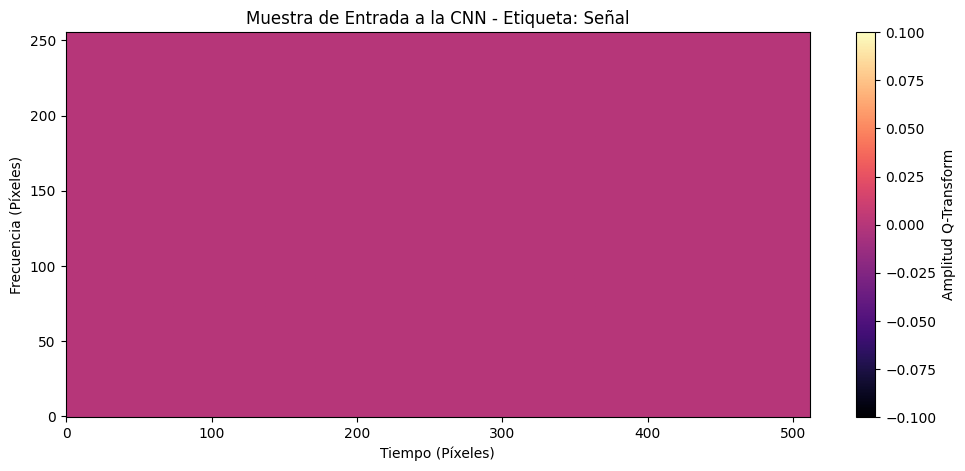

In [29]:
# Visualizar la primera imagen del lote
plt.figure(figsize=(12, 5))
# Quitamos el último canal (que es 1) para que matplotlib pueda dibujarlo
img_to_plot = images[0].numpy().squeeze() 

plt.imshow(img_to_plot, aspect='auto', cmap='magma', origin='lower', 
           vmin=np.percentile(img_to_plot, 5), vmax=np.percentile(img_to_plot, 95))
plt.title(f"Muestra de Entrada a la CNN - Etiqueta: {'Señal' if labels[0]==1 else 'Ruido'}")
plt.xlabel("Tiempo (Píxeles)")
plt.ylabel("Frecuencia (Píxeles)")
plt.colorbar(label='Amplitud Q-Transform')
plt.show()

## 2. Construcción e Inspección de la ResNet-18

La red neuronal convolucional residual (ResNet) resuelve el problema del desvanecimiento del gradiente mediante "conexiones atajo" (skip connections). Hemos diseñado una versión optimizada para nuestros espectrogramas de $256 \times 512$.

Vamos a instanciarla y ver su estructura ("Summary").

In [3]:
# Instanciamos el modelo con los valores por defecto
# Nota: Para el prototipado, desactivamos el gradient checkpointing para ver la estructura normal
model = build_resnet18_classifier(
    input_shape=TARGET_SHAPE,
    dense_units=128,
    dropout_rate=0.3,
    l2_reg=1e-4,
    use_checkpointing=False 
)

# Compilamos el modelo (necesario aunque solo hagamos inferencia)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Imprimir el resumen
model.summary()

Modelo ResNet-18 construido. Gradient Checkpointing: DESACTIVADO


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 512, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 256, 64)   │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_1_layer_1 (ResidualBlock) │ (None, 64, 128, 64)    │        78,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_1_layer_2 (ResidualBlock) │ (None, 64, 128, 64)    │        78,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_2_layer_1 (ResidualBlock) │ (None, 32, 64, 128)    │       231,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_2_layer_2 (ResidualBlock) │ (None, 32, 64, 128)    │       313,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_3_layer_1 (ResidualBlock) │ (None, 16, 32, 256)    │       921,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_3_layer_2 (ResidualBlock) │ (None, 16, 32, 256)    │     1,249,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_4_layer_1 (ResidualBlock) │ (None, 8, 16, 512)     │     3,677,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_4_layer_2 (ResidualBlock) │ (None, 8, 16, 512)     │     4,988,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,607,809 (44.28 MB)

 Trainable params: 11,596,161 (44.24 MB)

 Non-trainable params: 11,648 (45.50 KB)

## 3. Prueba de Inferencia (Forward Pass)

Para asegurarnos de que la arquitectura está libre de errores de dimensiones (muy comunes al pasar de las capas convolucionales a las capas densas), vamos a introducir nuestro lote de imágenes en la red sin entrenar.

El resultado esperado es un array de probabilidades (valores entre 0 y 1) con la misma longitud que nuestro Batch Size.

In [4]:
# Pasamos las imágenes por la red
predicciones = model.predict(images)

print("\n--- Resultados del Forward Pass ---")
print(f"Forma de la salida: {predicciones.shape} -> (Batch Size, Predicción)")

for i in range(BATCH_SIZE):
    print(f"Muestra {i+1} | Etiqueta Real: {labels[i].numpy()} | Probabilidad Predicha (Sin entrenar): {predicciones[i][0]:.4f}")
    
print("\n¡El pipeline de datos y la arquitectura están perfectamente acoplados!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step

--- Resultados del Forward Pass ---
Forma de la salida: (4, 1) -> (Batch Size, Predicción)
Muestra 1 | Etiqueta Real: 1 | Probabilidad Predicha (Sin entrenar): 0.5000
Muestra 2 | Etiqueta Real: 0 | Probabilidad Predicha (Sin entrenar): 0.5000
Muestra 3 | Etiqueta Real: 1 | Probabilidad Predicha (Sin entrenar): 0.5000
Muestra 4 | Etiqueta Real: 1 | Probabilidad Predicha (Sin entrenar): 0.5000

¡El pipeline de datos y la arquitectura están perfectamente acoplados!
